# Load data from InfluxDB

In [338]:
%pip install influxdb-client


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [339]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "BkQo1WObUd_cdaOmW3tQfymyGavrrPCmEqPsZwRS3-yTHZzECj5j_6X8MLQRdhbYtTnxKR6rDSi6Wne7g03VBA=="

# Initialize the client
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [340]:
# 1. Define the dynamic variables in the params dictionary
time_start = "-2000h"
time_stop = "now()"
window = "1s"

# 2. Define the query using the v.variable syntax
query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "sensor_data")
  |> filter(fn: (r) => r["_field"] =~ /(q|qd)_actual_joint_[0-5]/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

query_ctrl_msgs = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "ctrl_msgs")
  |> filter(fn: (r) =>
      r["msg_type"] == "play" or
      r["_field"] == "acceleration" or
      r["_field"] == "max_velocity"
  )
  |> drop(columns: ["msg_type"]) // Necessary because both a tag and a _field has the name "msg_type"
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
  |> sort(columns: ["_time"])
  |> fill(column: "acceleration", usePrevious: true)
  |> fill(column: "max_velocity", usePrevious: true)
  |> filter(fn: (r) => r["msg_type"] == "play")
'''

# 3. Execute and return as a DataFrame
df_sensor_data = query_api.query_data_frame(query_sensor_data)
df_ctrl_msgs = query_api.query_data_frame(query_ctrl_msgs)


# Show data

In [341]:
print(df_ctrl_msgs.head())

    result  table                           _start  \
0  _result      0 2026-01-01 03:09:58.419652+00:00   
1  _result      0 2026-01-01 03:09:58.419652+00:00   
2  _result      0 2026-01-01 03:09:58.419652+00:00   
3  _result      0 2026-01-01 03:09:58.419652+00:00   
4  _result      0 2026-01-01 03:09:58.419652+00:00   

                             _stop                            _time  \
0 2026-03-25 11:09:58.419652+00:00 2026-03-17 10:26:18.834355+00:00   
1 2026-03-25 11:09:58.419652+00:00 2026-03-17 10:27:58.829609+00:00   
2 2026-03-25 11:09:58.419652+00:00 2026-03-17 10:29:38.831772+00:00   
3 2026-03-25 11:09:58.419652+00:00 2026-03-17 10:31:18.833505+00:00   
4 2026-03-25 11:09:58.419652+00:00 2026-03-17 10:32:58.835176+00:00   

  _measurement                 source  acceleration  max_velocity msg_type  
0    ctrl_msgs  data_recorder_service     32.588224    141.482204     play  
1    ctrl_msgs  data_recorder_service     87.786853    155.504088     play  
2    ctrl_msgs  d

In [342]:
print(df_sensor_data.head())


    result  table                            _time  \
0  _result      0 2026-03-17 10:25:57.156264+00:00   
1  _result      0 2026-03-17 10:25:57.205907+00:00   
2  _result      0 2026-03-17 10:25:57.255828+00:00   
3  _result      0 2026-03-17 10:25:57.304806+00:00   
4  _result      0 2026-03-17 10:25:57.354614+00:00   

                            _start                            _stop  \
0 2026-01-01 03:09:52.710320+00:00 2026-03-25 11:09:52.710320+00:00   
1 2026-01-01 03:09:52.710320+00:00 2026-03-25 11:09:52.710320+00:00   
2 2026-01-01 03:09:52.710320+00:00 2026-03-25 11:09:52.710320+00:00   
3 2026-01-01 03:09:52.710320+00:00 2026-03-25 11:09:52.710320+00:00   
4 2026-01-01 03:09:52.710320+00:00 2026-03-25 11:09:52.710320+00:00   

  _measurement                 source  q_actual_joint_0  q_actual_joint_1  \
0  sensor_data  data_recorder_service     -7.869745e-08             -1.57   
1  sensor_data  data_recorder_service     -6.004316e-09             -1.57   
2  sensor_data  d

In [343]:
sensor_data_np = df_sensor_data.to_numpy()
start_msgs_timestamps = df_ctrl_msgs["_time"].to_list()

In [344]:
sensor_data_np.shape

(378367, 19)

In [345]:
sensor_data_np[0, :]

array(['_result', 0,
       Timestamp('2026-03-17 10:25:57.156264+0000', tz='UTC'),
       Timestamp('2026-01-01 03:09:52.710320+0000', tz='UTC'),
       Timestamp('2026-03-25 11:09:52.710320+0000', tz='UTC'),
       'sensor_data', 'data_recorder_service', -7.869744661578132e-08,
       -1.570000022745029, 1.570000180758667, -1.5699999561369649,
       -1.5700000002426153, 3.470370523656083e-08, 0.0, 0.0, 0.0, 0.0,
       0.0, 0.0], dtype=object)

In [346]:
start_msgs_timestamps

[Timestamp('2026-03-17 10:26:18.834355+0000', tz='UTC'),
 Timestamp('2026-03-17 10:27:58.829609+0000', tz='UTC'),
 Timestamp('2026-03-17 10:29:38.831772+0000', tz='UTC'),
 Timestamp('2026-03-17 10:31:18.833505+0000', tz='UTC'),
 Timestamp('2026-03-17 10:32:58.835176+0000', tz='UTC'),
 Timestamp('2026-03-17 10:34:38.839577+0000', tz='UTC'),
 Timestamp('2026-03-17 10:36:18.840639+0000', tz='UTC'),
 Timestamp('2026-03-17 10:37:58.843422+0000', tz='UTC'),
 Timestamp('2026-03-17 10:39:38.847001+0000', tz='UTC'),
 Timestamp('2026-03-17 10:41:18.847638+0000', tz='UTC'),
 Timestamp('2026-03-17 10:42:58.852316+0000', tz='UTC'),
 Timestamp('2026-03-17 10:44:38.855299+0000', tz='UTC'),
 Timestamp('2026-03-17 10:46:18.856437+0000', tz='UTC'),
 Timestamp('2026-03-17 10:47:58.857226+0000', tz='UTC'),
 Timestamp('2026-03-17 10:49:38.861492+0000', tz='UTC'),
 Timestamp('2026-03-17 10:51:18.864402+0000', tz='UTC'),
 Timestamp('2026-03-17 10:52:58.864931+0000', tz='UTC'),
 Timestamp('2026-03-17 12:36:09

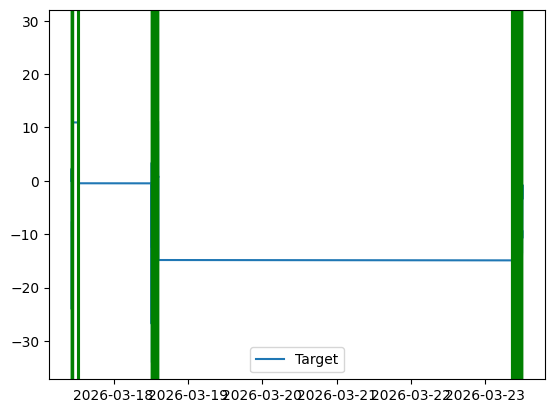

In [347]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, 2], sensor_data_np[lower_bound:upper_bound, -7], label="Target")
for movement_start in start_msgs_timestamps:
    plt.axvline(movement_start, color="g")

plt.legend()

# Determine end of movements
From observing the PT mockup, we have determined that all joints take the same amount of time to move.

In [348]:
import copy
# Translate timestamps into indexes
start_indexes = []
start_timestamps = copy.deepcopy(start_msgs_timestamps)

for n in range(sensor_data_np.shape[0] - 1):
    time_at_n = sensor_data_np[n, 2]
    time_at_n_plus_1 = sensor_data_np[n+1, 2]
    if time_at_n <= start_timestamps[0] <= time_at_n_plus_1:
        start_indexes.append(n)
        start_timestamps.pop(0)
    if len(start_timestamps) == 0:
        break

In [349]:
start_indexes

[431,
 2424,
 4415,
 6407,
 8400,
 10390,
 12382,
 14374,
 16368,
 18361,
 20353,
 22345,
 24336,
 26329,
 28320,
 30312,
 32301,
 34203,
 35994,
 37908,
 39900,
 41891,
 43883,
 45877,
 47868,
 49836,
 51826,
 53817,
 55808,
 57798,
 59790,
 61782,
 63772,
 65760,
 67751,
 69741,
 71730,
 73721,
 75712,
 77704,
 79695,
 81681,
 83670,
 85659,
 87649,
 89640,
 91630,
 93619,
 95609,
 97600,
 99590,
 101578,
 103567,
 105554,
 107541,
 109530,
 111519,
 113510,
 115499,
 117492,
 119482,
 121470,
 123461,
 125451,
 127443,
 129436,
 131424,
 133413,
 135404,
 137394,
 139385,
 141375,
 143366,
 145359,
 147352,
 149344,
 151331,
 153322,
 155311,
 157303,
 159294,
 161286,
 163278,
 165269,
 167259,
 169250,
 171242,
 173233,
 175225,
 177214,
 179202,
 181193,
 183182,
 185172,
 187165,
 189156,
 191143,
 193131,
 195090,
 197079,
 199073,
 201066,
 203059,
 205049,
 207038,
 209030,
 211023,
 213017,
 215008,
 216999,
 218990,
 220981,
 222974,
 224965,
 226954,
 228945,
 230933,
 232

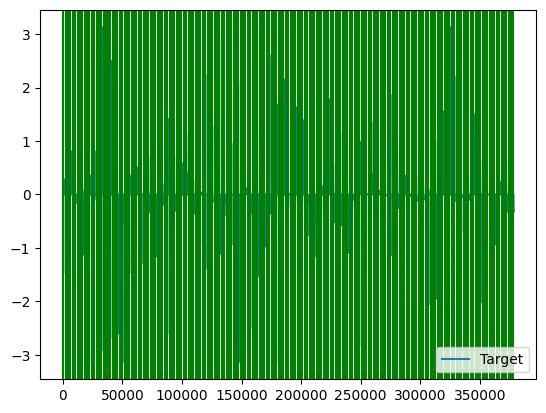

In [350]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i in start_indexes:
    plt.axvline(i, color="g")

plt.legend()

In [351]:
def determine_movement_ends(joint_vels: np.ndarray, start_indexes: list, threshold=1e-3, window=5):
    end_timestamps = []
    
    # Combine into a single speed since every joint finishes moving at the same time
    speed = np.linalg.norm(joint_vels, axis=1)
    
    for i in start_indexes:
        # Only look at data occurring after the start of this specific movement
        post_start_speed = speed[i:]
        
        # Find where speed drops below the threshold
        under_threshold = post_start_speed < threshold
        
        # To avoid mid-motion zero-crossings, ensure speed stays low for 'window' frames
        # We use a logical convolution to find a sequence of 'True' values
        is_settled = np.convolve(under_threshold, np.ones(window), mode='valid') == window
        
        # Find the first index where the 'settled' condition is met
        settled_indices = np.where(is_settled)[0]
        
        if settled_indices.size > 0:
            # We add 'ts' to get the global index, and 'window' isn't strictly 
            # necessary but helps point to the actual start of the stillness
            end_timestamps.append(i + settled_indices[0])
        else:
            # Fallback to end of array if no stop is detected
            end_timestamps.append(len(joint_vels) - 1)
            
    return end_timestamps

[431, 2424, 4415, 6407, 8400, 10390, 12382, 14374, 16368, 18361, 20353, 22345, 24336, 26329, 28320, 30312, 32301, 34203, 35994, 37908, 39900, 41891, 43883, 45877, 47868, 49836, 51826, 53817, 55808, 57798, 59790, 61782, 63772, 65760, 67751, 69741, 71730, 73721, 75712, 77704, 79695, 81681, 83670, 85659, 87649, 89640, 91630, 93619, 95609, 97600, 99590, 101578, 103567, 105554, 107541, 109530, 111519, 113510, 115499, 117492, 119482, 121470, 123461, 125451, 127443, 129436, 131424, 133413, 135404, 137394, 139385, 141375, 143366, 145359, 147352, 149344, 151331, 153322, 155311, 157303, 159294, 161286, 163278, 165269, 167259, 169250, 171242, 173233, 175225, 177214, 179202, 181193, 183182, 185172, 187165, 189156, 191143, 193131, 195090, 197079, 199073, 201066, 203059, 205049, 207038, 209030, 211023, 213017, 215008, 216999, 218990, 220981, 222974, 224965, 226954, 228945, 230933, 232923, 234915, 236905, 238897, 240887, 242878, 244868, 246858, 248847, 250837, 252829, 254819, 256813, 258806, 260797, 

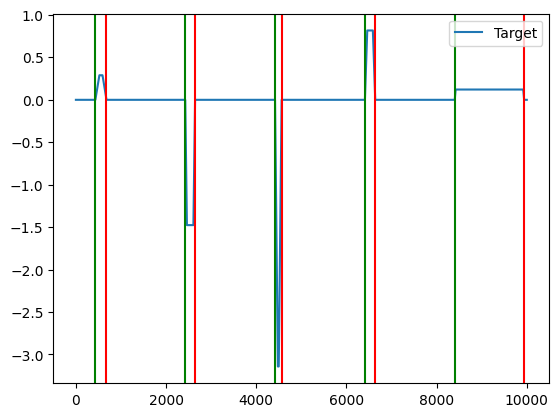

In [352]:
lower_bound = 0
upper_bound = 10000

joint_vels = sensor_data_np[:, -6:]
joint_vels = joint_vels.astype(np.float64)

end_indexes = determine_movement_ends(joint_vels, start_indexes)

print(start_indexes)
print(end_indexes)

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i, _ in enumerate(start_indexes):
    if lower_bound < start_indexes[i] < upper_bound:
        plt.axvline(start_indexes[i], color="g")
    if lower_bound < end_indexes[i] < upper_bound:
        plt.axvline(end_indexes[i], color="r")


plt.legend()

# Declaring data needed for training

We want to train a model to predict the time it takes to do a certain movement. Thus we now need to extract, the time a movement takes, and the start and end position

In [353]:
# Extract time
# This is easy as it is just the difference between the start and end timesteps of movements
start_positions = []
end_positions = []
movement_time = []

joint_positions = sensor_data_np[:, -12:-6]

for i, _ in enumerate(start_indexes):
    # Determine time taken
    time_taken = sensor_data_np[end_indexes[i], 2] - sensor_data_np[start_indexes[i], 2]
    movement_time.append(time_taken.total_seconds()) # save time taken in seconds

    # Extract start and end pos
    start_pos = joint_positions[start_indexes[i], :]
    start_positions.append(start_pos)

    end_pos = joint_positions[end_indexes[i], :]
    end_positions.append(end_pos)


print(f"{movement_time=}\n")
print(f"{start_positions=}\n")
print(f"{end_positions=}\n")

movement_time=[12.344599, 10.870025, 7.273785, 11.496336, 77.30096, 18.416548, 215.377237, 115.374988, 15.36452, 84.026351, 7.628875, 10.106963, 11.337089, 14.740743, 10.255264, 7.285003, 16.171886, 16.315179, 24.062694, 14.304842, 15.069363, 8.144794, 12.756941, 13.590513, 18.148735, 17.639339, 6.718159, 117.42603, 17.406435, 10.459324, 13.690844, 17.965654, 13.610448, 12.219281, 110.287605, 10.29358, 30.265785, 27.590475, 59.345978, 15.506838, 274.119421, 174.14292, 74.128635, 11.317986, 17.738279, 11.452232, 57.440089, 12.457502, 41.558183, 26.187246, 26.832273999999998, 20.665805, 13.902479, 21.146429, 13.653911, 18.608152, 11.253144, 11.04926, 11.056997, 8.16522, 4.684502, 8.597743, 30.219146, 112.856484, 12.852437, 13.741622, 11.576935, 9.310917, 15.166312, 111.189351, 11.156088, 4.532872, 9.938528, 7.594452, 11.909895, 7.99543, 10.493146, 18.029148, 51.789622, 15.055561, 13.109838, 9.579767, 10.872195, 17.356921, 46.699802, 9.22623, 31.683202, 42.119255, 5.598008, 9.795414, 12.8

In [354]:
start_positions[0]

array([1.3019280147000384e-06, -1.570002385012374, 1.5699981579699005,
       -1.5700015653641934, -1.5699986279975142, 1.3768857308362917e-06],
      dtype=object)

In [355]:
end_positions[0]

array([-19.589244719182247, -17.538457817971878, -11.278325832773644,
       5.377998035834856, -19.439139269287235, 2.2972116961366527],
      dtype=object)

# Plot of correlation between the max distance a joint has to move and the time the movement takes.

In [356]:
max_position_diff = []

for i, _ in enumerate(start_positions):
    max_diff = np.max(np.abs(end_positions[i] - start_positions[i]))
    max_position_diff.append(max_diff)

max_position_diff

[19.589246021110263,
 24.567304947611852,
 12.994712897033665,
 21.14116885373777,
 37.74936264222374,
 38.03649457760818,
 37.93808140616521,
 43.4247390452374,
 44.06555353132393,
 28.320445829381697,
 19.046018696512135,
 27.38804823915408,
 19.91597648192287,
 29.67313403894286,
 17.890343624904013,
 18.573606620529866,
 26.473814920892007,
 31.23418892862354,
 23.426616158746985,
 38.276735157036555,
 37.83397010556153,
 18.36765110802852,
 28.47093121071616,
 39.216964657474506,
 49.58288078799039,
 31.413445311681013,
 16.310721378741796,
 20.793825216643867,
 18.678023329122603,
 29.05284130866496,
 28.874042213783312,
 38.348682166632955,
 37.97416186506091,
 32.43582247984723,
 34.65355612471746,
 27.664094151829122,
 30.654732894479814,
 19.258353204345468,
 46.658784540995676,
 42.57799619647549,
 41.60814884127434,
 39.84469241512122,
 31.114739666785574,
 28.27261904596439,
 40.45474640412016,
 31.26776553270073,
 20.811597398773895,
 34.172439943791034,
 43.2104133596418

Text(0.5, 0, 'Max angle difference (rad)')

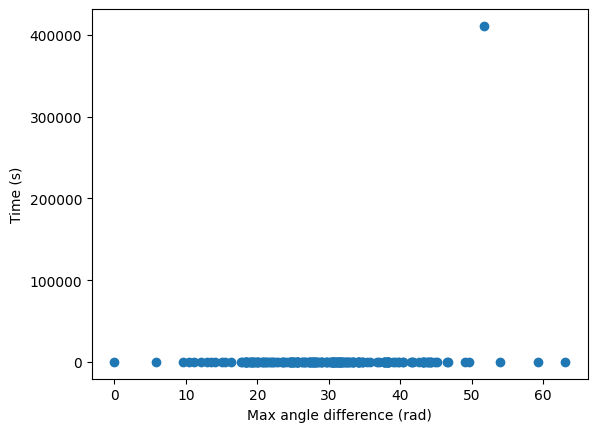

In [357]:
plt.scatter(max_position_diff, movement_time)
plt.ylabel("Time (s)")
plt.xlabel("Max angle difference (rad)")

In [358]:
# Form input data to model
accelerations = df_ctrl_msgs["acceleration"].to_list()
max_velocities = df_ctrl_msgs["max_velocity"].to_list()

def transpose_list(l: list):
    return list(map(list, zip(*l)))


input_data = transpose_list([max_position_diff, accelerations, max_velocities])
len(input_data), len(input_data[0])

(191, 3)

In [359]:
# Remove large outliers
for i, diff in enumerate(movement_time):
    if diff > 100000:
        input_data.pop(i)
        movement_time.pop(i)
        break

(len(input_data), len(input_data[0])), len(movement_time)

((190, 3), 190)

Text(0.5, 0, 'Max angle difference (rad)')

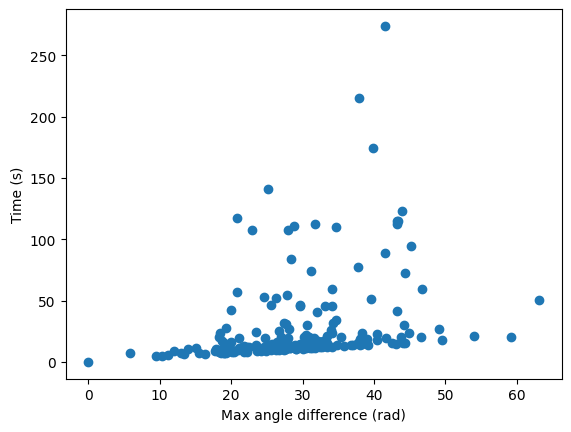

In [360]:
plt.scatter(np.array(input_data)[:, 0], movement_time)
plt.ylabel("Time (s)")
plt.xlabel("Max angle difference (rad)")

## Proposing model

Since it does not look like a nice linear correlation, we will throw a neural network at it. In this case, the architecture will be based on the MLP.

In [361]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split

## Create Datasets

In [362]:
class MovementDataset(Dataset):
    def __init__(self, input_data: torch.tensor, movement_time: torch.tensor):
        self.input_data = input_data
        self.movement_time = movement_time

    def __len__(self):
        return len(self.input_data)

    def __getitem__(self, idx):
        return self.input_data[idx], self.movement_time[idx]


ds = MovementDataset(torch.tensor(input_data), torch.tensor(movement_time))

for diffs, times in ds:
    print(diffs, times)

train_ds, val_ds, test_ds = random_split(ds, [0.7, 0.15, 0.15])

tensor([ 19.5892,  32.5882, 141.4822]) tensor(12.3446)
tensor([ 24.5673,  87.7868, 155.5041]) tensor(10.8700)
tensor([ 12.9947,  58.5464, 316.7597]) tensor(7.2738)
tensor([ 21.1412,  54.1337, 136.9685]) tensor(11.4963)
tensor([37.7494, 31.6397, 28.4703]) tensor(77.3010)
tensor([ 38.0365, 114.7485, 126.4527]) tensor(18.4165)
tensor([37.9381, 14.9556,  3.1610]) tensor(215.3772)
tensor([43.4247, 80.6952,  9.7961]) tensor(115.3750)
tensor([ 44.0656, 147.0000, 266.2722]) tensor(15.3645)
tensor([28.3204, 90.7204, 19.4432]) tensor(84.0264)
tensor([ 19.0460, 118.4685, 212.7815]) tensor(7.6289)
tensor([ 27.3880, 130.9819, 251.8973]) tensor(10.1070)
tensor([ 19.9160,  36.4130, 288.2519]) tensor(11.3371)
tensor([ 29.6731,  34.6383, 209.2212]) tensor(14.7407)
tensor([ 17.8903,  92.5432, 114.8229]) tensor(10.2553)
tensor([ 18.5736, 136.3776, 304.6447]) tensor(7.2850)
tensor([ 26.4738,  23.5183, 322.3869]) tensor(16.1719)
tensor([ 31.2342, 151.5069, 217.0070]) tensor(16.3152)
tensor([ 23.4266, 140.2

## Create Dataloaders

In [363]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

## Define Model Architecture

In [364]:
from torch.nn import Linear, LeakyReLU

class Model(torch.nn.Module):
    def __init__(self):
        super(Model, self).__init__()

        self.linear1 = Linear(3, 20)
        self.linear2 = Linear(20, 12)
        self.linear3 = Linear(12, 1)
        self.activation = LeakyReLU()

    def forward(self, x):
        x = self.activation(self.linear1(x))
        x = self.activation(self.linear2(x))
        x = self.activation(self.linear3(x))
        return x
        

## Train Model

In [369]:
def train(model: torch.nn.Module, train_loader: DataLoader, val_loader: DataLoader, loss_fn, optim, scheduler, n_epochs: int = 50):
    model.train()
    for i in range(n_epochs):
        train_loss = train_epoch(model, train_loader, loss_fn, optim)
        val_mae = test(model, val_loader)
        scheduler.step()
        print(f"Train loss: {train_loss}, Val MAE: {val_mae}")

def train_epoch(model: torch.nn.Module, train_loader: DataLoader, loss_fn, optim):
    cumulated_loss = 0
    for X, y in train_loader:
        optim.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optim.step()
        cumulated_loss += loss.item()
    return cumulated_loss

def test(model, dataloader: DataLoader):
    model.eval()
    absolute_errors = torch.tensor([])
    for X, y in dataloader:
        y_pred = model(X).squeeze()
        absolute_errors = torch.cat([absolute_errors, torch.abs(y - y_pred)], 0)
    mae = torch.mean(absolute_errors)
    return mae.item()

In [370]:
model = Model()
loss_fn = torch.nn.MSELoss()
optim = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, gamma=0.95)
train(model, train_loader, val_loader, loss_fn, optim, scheduler, n_epochs=1000)

/home/losmobilos3/Desktop/Engineering Digital Twins/UR3eDTCourse/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/losmobilos3/Desktop/Engineering Digital Twins/UR3eDTCourse/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([6])) that is different to the input size (torch.Size([6, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Train loss: 22665.18603515625, Val MAE: 24.13680076599121
Train loss: 18220.660583496094, Val MAE: 32.41604232788086
Train loss: 15825.430282592773, Val MAE: 23.440135955810547
Train loss: 15362.247863769531, Val MAE: 24.459869384765625
Train loss: 15583.546569824219, Val MAE: 27.924392700195312
Train loss: 17081.14337158203, Val MAE: 24.679702758789062
Train loss: 15308.605407714844, Val MAE: 23.618528366088867
Train loss: 16160.259216308594, Val MAE: 23.291399002075195
Train loss: 15101.833709716797, Val MAE: 26.270097732543945
Train loss: 14783.08251953125, Val MAE: 24.91034507751465
Train loss: 15586.68424987793, Val MAE: 23.103382110595703
Train loss: 15014.671508789062, Val MAE: 24.603179931640625
Train loss: 14931.015380859375, Val MAE: 22.244518280029297
Train loss: 14995.483276367188, Val MAE: 20.919876098632812
Train loss: 21038.87518310547, Val MAE: 22.56549644470215
Train loss: 15233.823272705078, Val MAE: 27.006113052368164
Train loss: 17028.70880126953, Val MAE: 22.373685

## Test Model

In [371]:
test_MAE = test(model, test_loader)

print(f"{test_MAE=}")

test_MAE=15.7123441696167
